# Linear Regression from Scratch: Gradient Descent

This notebook introduces linear regression in a very intuitive way.

## Learning goals

By the end of this notebook, students should be able to:

1. explain the equation of a simple linear regression model,
2. calculate predictions and errors,
3. understand the Mean Squared Error (MSE) loss,
4. update model parameters using gradient descent,
5. extend the idea from one feature to two features,
6. compare the from-scratch idea with scikit-learn resources.

We use the MSE loss:

$$
L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$

Because we use MSE without the extra factor $\frac{1}{2}$, the gradients contain a factor of 2.


## Setup

We only need `numpy` and `matplotlib` for the main lesson.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Section 1 — Simple Linear Regression with One Feature

We start with one input feature:

$$
\hat{y} = w_1x_1 + b
$$

Where:

- $x_1$ is the input feature,
- $w_1$ is the weight,
- $b$ is the bias,
- $\hat{y}$ is the prediction.


## 1.1 Tiny dataset

We use a very small dataset:

| $x_1$ | true $y$ |
|---:|---:|
| 1 | 2 |
| 2 | 4 |
| 3 | 6 |

The hidden pattern is:

$$
y = 2x
$$

But the model does not know this yet.


In [2]:
# Tiny dataset
x = np.array([1, 2, 3], dtype=float)
y = np.array([2, 4, 6], dtype=float)

print("x:", x)
print("y:", y)

x: [1. 2. 3.]
y: [2. 4. 6.]


## 1.2 Start with a bad model

We start with:

$$
w = 0, \quad b = 0
$$

So the first model is:

$$
\hat{y} = 0x + 0
$$


In [3]:
w = 0.0
b = 0.0

y_pred = w * x + b

print("Initial predictions:", y_pred)

Initial predictions: [0. 0. 0.]


## 1.3 Calculate error and MSE loss

The error is:

$$
error = \hat{y} - y
$$

The MSE loss is:

$$
L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$


In [4]:
error = y_pred - y
loss = np.mean(error ** 2)

print("Errors:", error)
print("MSE loss:", loss)

Errors: [-2. -4. -6.]
MSE loss: 18.666666666666668


Manual calculation:

$$
L = \frac{1}{3}\left[(-2)^2 + (-4)^2 + (-6)^2\right]
$$

$$
L = \frac{1}{3}(4 + 16 + 36) = \frac{56}{3} = 18.67
$$


## 1.4 Gradient descent update

For MSE, the gradients are:

$$
\frac{\partial L}{\partial w_1} = 2 \cdot average(error \cdot x)
$$

$$
\frac{\partial L}{\partial b} = 2 \cdot average(error)
$$

The update rules are:

$$
w_1 := w_1 - \alpha \frac{\partial L}{\partial w_1}
$$

$$
b := b - \alpha \frac{\partial L}{\partial b}
$$

where $\alpha$ is the learning rate.


In [5]:
learning_rate = 0.1

grad_w = 2 * np.mean(error * x)
grad_b = 2 * np.mean(error)

print("Gradient for w:", grad_w)
print("Gradient for b:", grad_b)

w = w - learning_rate * grad_w
b = b - learning_rate * grad_b

print("Updated w:", w)
print("Updated b:", b)

Gradient for w: -18.666666666666668
Gradient for b: -8.0
Updated w: 1.866666666666667
Updated b: 0.8


After one update, the model becomes approximately:

$$
\hat{y} = 1.867x + 0.8
$$

This is already much closer than the initial model.


## 1.5 Train for several epochs

An **epoch** means one full update step using the whole dataset.


In [6]:
# Re-initialize parameters
w = 0.0
b = 0.0

learning_rate = 0.1
epochs = 20

loss_history = []
w_history = []
b_history = []

for epoch in range(epochs):
    # Prediction
    y_pred = w * x + b

    # Error
    error = y_pred - y

    # MSE loss
    loss = np.mean(error ** 2)

    # Gradients
    grad_w = 2 * np.mean(error * x)
    grad_b = 2 * np.mean(error)

    # Update
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    # Store history
    loss_history.append(loss)
    w_history.append(w)
    b_history.append(b)

    print(f"Epoch {epoch+1:2d}: w = {w:.4f}, b = {b:.4f}, loss = {loss:.4f}")

print("\nFinal model:")
print(f"y_hat = {w:.4f} * x + {b:.4f}")

Epoch  1: w = 1.8667, b = 0.8000, loss = 18.6667
Epoch  2: w = 1.6711, b = 0.6933, loss = 0.2963
Epoch  3: w = 1.7007, b = 0.6862, loss = 0.0734
Epoch  4: w = 1.7056, b = 0.6687, loss = 0.0674
Epoch  5: w = 1.7129, b = 0.6527, loss = 0.0642
Epoch  6: w = 1.7198, b = 0.6370, loss = 0.0611
Epoch  7: w = 1.7265, b = 0.6217, loss = 0.0582
Epoch  8: w = 1.7331, b = 0.6068, loss = 0.0554
Epoch  9: w = 1.7395, b = 0.5922, loss = 0.0528
Epoch 10: w = 1.7458, b = 0.5779, loss = 0.0503
Epoch 11: w = 1.7519, b = 0.5640, loss = 0.0479
Epoch 12: w = 1.7578, b = 0.5505, loss = 0.0456
Epoch 13: w = 1.7637, b = 0.5373, loss = 0.0435
Epoch 14: w = 1.7693, b = 0.5243, loss = 0.0414
Epoch 15: w = 1.7749, b = 0.5117, loss = 0.0394
Epoch 16: w = 1.7803, b = 0.4994, loss = 0.0376
Epoch 17: w = 1.7856, b = 0.4874, loss = 0.0358
Epoch 18: w = 1.7907, b = 0.4757, loss = 0.0341
Epoch 19: w = 1.7958, b = 0.4643, loss = 0.0325
Epoch 20: w = 1.8007, b = 0.4531, loss = 0.0309

Final model:
y_hat = 1.8007 * x + 0.45

## 1.6 Visualization: data points and learned line

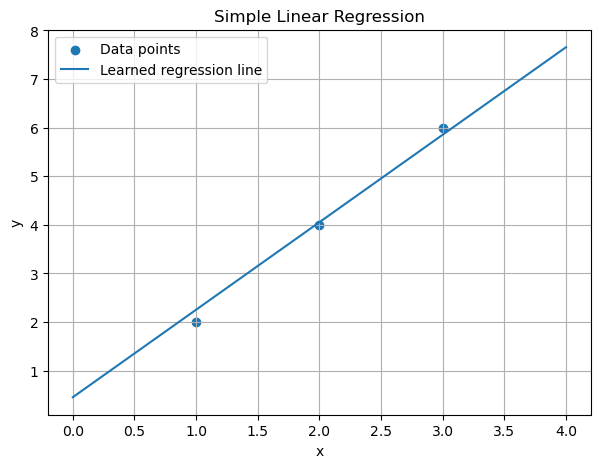

In [7]:
x_line = np.linspace(0, 4, 100)
y_line = w * x_line + b

plt.figure(figsize=(7, 5))
plt.scatter(x, y, label="Data points")
plt.plot(x_line, y_line, label="Learned regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

## 1.7 Visualization: loss during training

The loss should generally go down as the model improves.


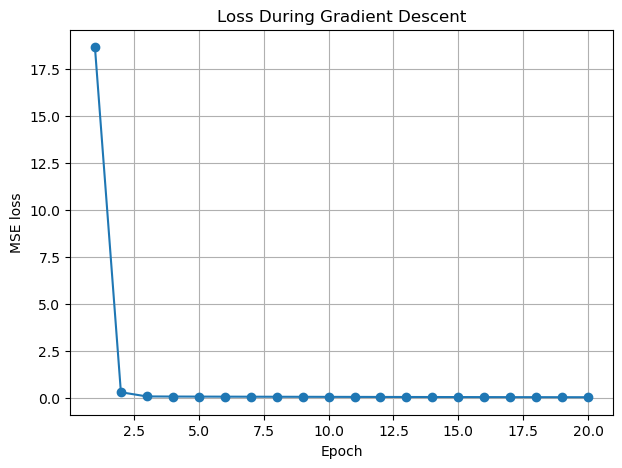

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Loss During Gradient Descent")
plt.grid(True)
plt.show()

## 1.8 Visualization: how the line changes

This plot shows how gradient descent gradually changes the regression line.


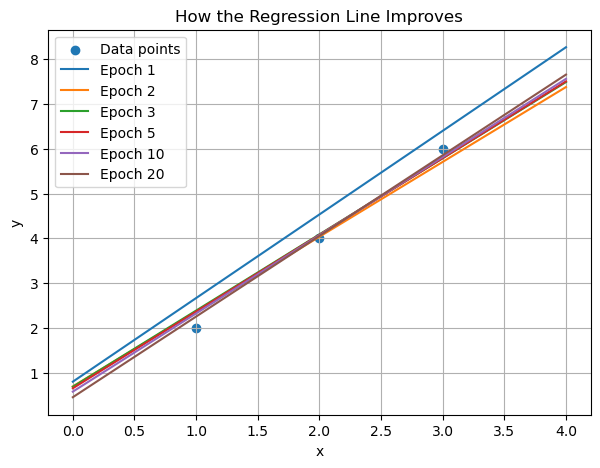

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, label="Data points")

selected_epochs = [0, 1, 2, 4, 9, 19]

for i in selected_epochs:
    y_temp = w_history[i] * x_line + b_history[i]
    plt.plot(x_line, y_temp, label=f"Epoch {i+1}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("How the Regression Line Improves")
plt.legend()
plt.grid(True)
plt.show()

## 1.9 Mini exercise

Change the following values and observe what happens:

1. Change `learning_rate` from `0.1` to `0.01`.
2. Change `learning_rate` from `0.1` to `0.5`.
3. Change the dataset to `x = [1, 2, 3, 4]` and `y = [3, 6, 9, 12]`.
4. Increase `epochs` from `20` to `100`.

Discussion questions:

- What happens if the learning rate is too small?
- What happens if the learning rate is too large?
- Does the loss always go down?


# Section 2 — Extension: Linear Regression with Two Features

Now we extend the model from one feature to two features.

The model becomes:

$$
\hat{y} = w_1x_1 + w_2x_2 + b
$$

Example interpretation:

- $x_1$ = hours of study,
- $x_2$ = number of practice exercises,
- $y$ = exam score.

This is still linear regression. We only add one more input feature.


## 2.1 Tiny dataset with two features

We create a tiny artificial dataset:

| $x_1$ | $x_2$ | true $y$ |
|---:|---:|---:|
| 1 | 1 | 6 |
| 2 | 1 | 8 |
| 1 | 2 | 9 |
| 3 | 2 | 13 |

The hidden pattern is:

$$
y = 2x_1 + 3x_2 + 1
$$

So ideally, the model should learn:

$$
w_1 \approx 2, \quad w_2 \approx 3, \quad b \approx 1
$$


In [10]:
# Tiny two-feature dataset
X = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [3, 2]
], dtype=float)

y = np.array([6, 8, 9, 13], dtype=float)

print("X:")
print(X)
print("y:", y)

X:
[[1. 1.]
 [2. 1.]
 [1. 2.]
 [3. 2.]]
y: [ 6.  8.  9. 13.]


## 2.2 Start with a bad model

We start with:

$$
w_1 = 0, \quad w_2 = 0, \quad b = 0
$$

So every prediction is initially 0.


In [11]:
w1 = 0.0
w2 = 0.0
b = 0.0

x1 = X[:, 0]
x2 = X[:, 1]

y_pred = w1 * x1 + w2 * x2 + b

print("Initial predictions:", y_pred)

Initial predictions: [0. 0. 0. 0.]


## 2.3 Calculate error and MSE loss

Again:

$$
error = \hat{y} - y
$$

and:

$$
L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$


In [12]:
error = y_pred - y
loss = np.mean(error ** 2)

print("Errors:", error)
print("MSE loss:", loss)

Errors: [ -6.  -8.  -9. -13.]
MSE loss: 87.5


Manual calculation:

The initial errors are:

$$
[-6, -8, -9, -13]
$$

So the MSE loss is:

$$
L = \frac{1}{4}\left[(-6)^2 + (-8)^2 + (-9)^2 + (-13)^2\right]
$$

$$
L = \frac{1}{4}(36 + 64 + 81 + 169)
$$

$$
L = \frac{350}{4} = 87.5
$$


## 2.4 Gradients for two features

For two features, we need three gradients:

$$
\frac{\partial L}{\partial w_1} = 2 \cdot average(error \cdot x_1)
$$

$$
\frac{\partial L}{\partial w_2} = 2 \cdot average(error \cdot x_2)
$$

$$
\frac{\partial L}{\partial b} = 2 \cdot average(error)
$$

The update rules are:

$$
w_1 := w_1 - \alpha \frac{\partial L}{\partial w_1}
$$

$$
w_2 := w_2 - \alpha \frac{\partial L}{\partial w_2}
$$

$$
b := b - \alpha \frac{\partial L}{\partial b}
$$


In [13]:
learning_rate = 0.01

grad_w1 = 2 * np.mean(error * x1)
grad_w2 = 2 * np.mean(error * x2)
grad_b = 2 * np.mean(error)

print("Gradient for w1:", grad_w1)
print("Gradient for w2:", grad_w2)
print("Gradient for b:", grad_b)

w1 = w1 - learning_rate * grad_w1
w2 = w2 - learning_rate * grad_w2
b = b - learning_rate * grad_b

print("\nUpdated parameters:")
print("w1:", w1)
print("w2:", w2)
print("b:", b)

Gradient for w1: -35.0
Gradient for w2: -29.0
Gradient for b: -18.0

Updated parameters:
w1: 0.35000000000000003
w2: 0.29
b: 0.18


After one update with learning rate `0.01`, we get approximately:

$$
w_1 = 0.35, \quad w_2 = 0.29, \quad b = 0.18
$$

The model is still not good, but it has started moving in the right direction.


## 2.5 Train the two-feature model for several epochs

In [14]:
# Re-initialize parameters
w1 = 0.0
w2 = 0.0
b = 0.0

learning_rate = 0.01
epochs = 100

loss_history_2d = []
w1_history = []
w2_history = []
b_history_2d = []

for epoch in range(epochs):
    # Prediction
    y_pred = w1 * x1 + w2 * x2 + b

    # Error
    error = y_pred - y

    # MSE loss
    loss = np.mean(error ** 2)

    # Gradients
    grad_w1 = 2 * np.mean(error * x1)
    grad_w2 = 2 * np.mean(error * x2)
    grad_b = 2 * np.mean(error)

    # Update
    w1 = w1 - learning_rate * grad_w1
    w2 = w2 - learning_rate * grad_w2
    b = b - learning_rate * grad_b

    # Store history
    loss_history_2d.append(loss)
    w1_history.append(w1)
    w2_history.append(w2)
    b_history_2d.append(b)

    # Print only selected epochs to keep the output short
    if epoch < 5 or (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:3d}: "
            f"w1 = {w1:.4f}, w2 = {w2:.4f}, b = {b:.4f}, loss = {loss:.4f}"
        )

print("\nFinal model:")
print(f"y_hat = {w1:.4f} * x1 + {w2:.4f} * x2 + {b:.4f}")

Epoch   1: w1 = 0.3500, w2 = 0.2900, b = 0.1800, loss = 87.5000
Epoch   2: w1 = 0.6515, w2 = 0.5409, b = 0.3354, loss = 65.2374
Epoch   3: w1 = 0.9112, w2 = 0.7579, b = 0.4697, loss = 48.6575
Epoch   4: w1 = 1.1347, w2 = 0.9458, b = 0.5857, loss = 36.3095
Epoch   5: w1 = 1.3271, w2 = 1.1085, b = 0.6859, loss = 27.1130
Epoch  20: w1 = 2.3712, w2 = 2.0592, b = 1.2549, loss = 0.5706
Epoch  40: w1 = 2.4321, w2 = 2.2383, b = 1.3330, loss = 0.1965
Epoch  60: w1 = 2.3798, w2 = 2.3107, b = 1.3465, loss = 0.1548
Epoch  80: w1 = 2.3285, w2 = 2.3704, b = 1.3541, loss = 0.1232
Epoch 100: w1 = 2.2834, w2 = 2.4232, b = 1.3592, loss = 0.0987

Final model:
y_hat = 2.2834 * x1 + 2.4232 * x2 + 1.3592


## 2.6 Visualization: loss during training

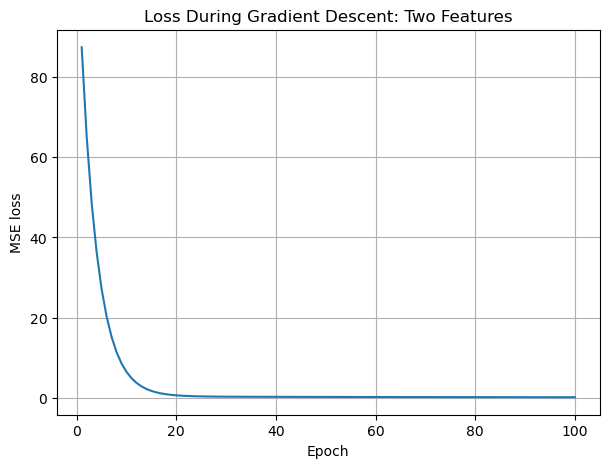

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), loss_history_2d)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Loss During Gradient Descent: Two Features")
plt.grid(True)
plt.show()

## 2.7 Visualization: predicted vs. true values

For two features, it is harder to draw a simple 2D line.  
A very intuitive alternative is to compare true values and predicted values.

If predictions are good, the predicted bars should be close to the true bars.


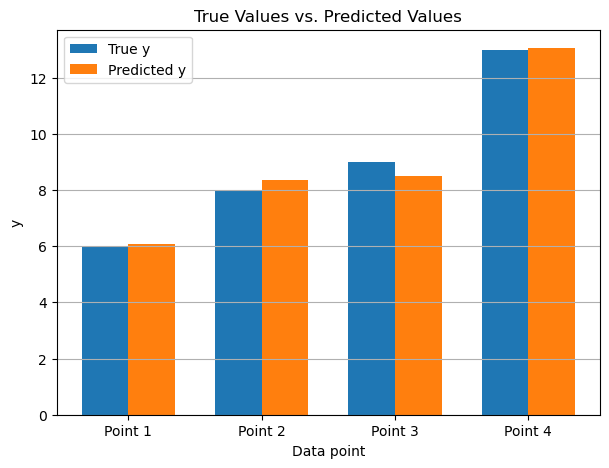

True y:      [ 6.  8.  9. 13.]
Predicted y: [ 6.066  8.349  8.489 13.056]


In [16]:
final_predictions = w1 * x1 + w2 * x2 + b

indices = np.arange(len(y))
bar_width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(indices - bar_width/2, y, width=bar_width, label="True y")
plt.bar(indices + bar_width/2, final_predictions, width=bar_width, label="Predicted y")
plt.xlabel("Data point")
plt.ylabel("y")
plt.title("True Values vs. Predicted Values")
plt.xticks(indices, [f"Point {i+1}" for i in indices])
plt.legend()
plt.grid(axis="y")
plt.show()

print("True y:     ", y)
print("Predicted y:", np.round(final_predictions, 3))

## 2.8 Optional: vectorized version

Instead of writing:

$$
\hat{y} = w_1x_1 + w_2x_2 + b
$$

we can use vectors:

$$
\hat{y} = Xw + b
$$

where:

$$
w = [w_1, w_2]
$$

This is how machine learning libraries usually implement it.


In [17]:
# Vectorized two-feature gradient descent

X = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [3, 2]
], dtype=float)

y = np.array([6, 8, 9, 13], dtype=float)

weights = np.array([0.0, 0.0])  # [w1, w2]
b = 0.0

learning_rate = 0.01
epochs = 100

loss_history_vectorized = []

for epoch in range(epochs):
    y_pred = X @ weights + b
    error = y_pred - y
    loss = np.mean(error ** 2)

    grad_weights = 2 * np.mean(error.reshape(-1, 1) * X, axis=0)
    grad_b = 2 * np.mean(error)

    weights = weights - learning_rate * grad_weights
    b = b - learning_rate * grad_b

    loss_history_vectorized.append(loss)

print("Final weights:", weights)
print("Final bias:", b)
print("Final loss:", loss_history_vectorized[-1])

Final weights: [2.28338016 2.4231626 ]
Final bias: 1.3592312257853216
Final loss: 0.09870064437246719


## 2.9 Mini exercise

Try the following:

1. Change the learning rate from `0.01` to `0.001`.
2. Change the learning rate from `0.01` to `0.1`.
3. Increase the number of epochs from `100` to `1000`.
4. Add a new data point that follows the same hidden pattern:
   - $x_1 = 4$
   - $x_2 = 3$
   - $y = 2 \cdot 4 + 3 \cdot 3 + 1 = 18$

Discussion questions:

- Why do we need one gradient for each weight?
- Why is the two-feature model harder to visualize?
- Why can the learning rate that works for one dataset fail for another dataset?


# Section 3 — References and Learning Resources

Start with official scikit-learn resources.

## scikit-learn examples and documentation

1. **Linear Regression Example**  
   Official example using `LinearRegression` and a simple two-dimensional plot.  
   https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html

2. **Linear Models User Guide**  
   Official explanation of linear models in scikit-learn. It introduces the general form:

   $$
   \hat{y}(w, x) = w_0 + w_1x_1 + \dots + w_px_p
   $$

   https://scikit-learn.org/stable/modules/linear_model.html

3. **LinearRegression API documentation**  
   Official documentation for `sklearn.linear_model.LinearRegression`.  
   https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

4. **Stochastic Gradient Descent User Guide**  
   Useful for connecting gradient descent ideas with scikit-learn's SGD implementation.  
   https://scikit-learn.org/stable/modules/sgd.html

5. **SGDRegressor API documentation**  
   Official documentation for regression with stochastic gradient descent.  
   https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html

## Recommended beginner learning path

1. First, understand simple linear regression with one feature.
2. Then, extend the model to multiple features.
3. Then, compare your from-scratch implementation with `sklearn.linear_model.LinearRegression`.
4. Finally, study `SGDRegressor` to connect gradient descent with a library implementation.

## Optional next step: compare with scikit-learn

The code below is optional. It requires scikit-learn to be installed.


In [18]:
# Optional: compare with scikit-learn LinearRegression

try:
    from sklearn.linear_model import LinearRegression

    X = np.array([
        [1, 1],
        [2, 1],
        [1, 2],
        [3, 2]
    ], dtype=float)

    y = np.array([6, 8, 9, 13], dtype=float)

    model = LinearRegression()
    model.fit(X, y)

    print("scikit-learn coefficients:", model.coef_)
    print("scikit-learn intercept:", model.intercept_)
    print("Predictions:", model.predict(X))

except ImportError:
    print("scikit-learn is not installed. Install it with: pip install scikit-learn")

scikit-learn coefficients: [2. 3.]
scikit-learn intercept: 0.9999999999999964
Predictions: [ 6.  8.  9. 13.]


## Final reflection questions

1. What is the role of the weight $w$?
2. What is the role of the bias $b$?
3. Why do we square the error?
4. Why do we average the squared errors?
5. What does the learning rate control?
6. Why does the two-feature model need two weights?
7. How is the from-scratch implementation connected to scikit-learn?
